# 04 — Финальный Pipeline
### Практическая часть дипломной работы

**Задачи:**
1. Загрузить все обученные модели (YOLOv8n, plates, ResNet18 x2, EasyOCR)
2. Обработать одиночный кадр — детекция + цвет + тип кузова + номер
3. Обработать видео — покадровый анализ
4. Статистика: распределения, скорость, сводная таблица

---
> **Предыдущие:** 01 → 02 → 03 | **Зависимости:** `yolov8n_plates.pt`, `color_resnet18.pth`, `body_resnet18.pth`

In [1]:
%%capture
!pip install -q ultralytics easyocr torch torchvision Pillow matplotlib seaborn pandas opencv-python-headless

In [2]:
import re, json, time, warnings
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights
from PIL import Image, ImageDraw, ImageFont
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from ultralytics import YOLO
import easyocr
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
try:
    from google.colab import output as _colab_out; IN_COLAB = True
    from google.colab.patches import cv2_imshow
except ImportError:
    IN_COLAB = False
    def cv2_imshow(img): plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.show()

COLOR_LABELS = ['black','white','silver','red','blue','yellow','green','brown','orange']
BODY_LABELS  = ['sedan','suv','hatchback','van','truck','minibus']

# ── Пути к моделям ────────────────────────────────────────────────────────────
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_MODELS = Path('/content/drive/MyDrive/diploma/models')
else:
    DRIVE_MODELS = Path('diploma_models')
DRIVE_MODELS.mkdir(parents=True, exist_ok=True)

_choice_json = DRIVE_MODELS / 'detector_choice.json'
if _choice_json.exists():
    with open(_choice_json) as _f:
        _choice = json.load(_f)
    VEHICLE_MODEL_PATH = _choice.get('vehicle_model', 'yolov8n.pt')
    PLATES_MODEL_PATH  = Path(_choice.get('plates_model',
                             str(DRIVE_MODELS / 'yolov8n_plates.pt')))
else:
    VEHICLE_MODEL_PATH = 'yolov8n.pt'
    PLATES_MODEL_PATH  = DRIVE_MODELS / 'yolov8n_plates.pt'
COLOR_MODEL_PATH   = DRIVE_MODELS / 'color_resnet18.pth'
BODY_MODEL_PATH    = DRIVE_MODELS / 'body_resnet18.pth'

OUTPUT_DIR = Path('diploma_04_pipeline/output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLATE_REGEX = re.compile(r'[АВЕКМНОРСТУХ]\d{3}[АВЕКМНОРСТУХ]{2}\d{2,3}')
# Транслитерация: латинские буквы → их кириллические визуальные двойники
LATIN_TO_CYR = str.maketrans('ABEKMHOPCTYX', 'АВЕКМНОРСТУХ')
VEHICLE_CLASSES = {2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}

INF_TF = T.Compose([
    T.Resize((224,224)), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# ── Шрифт для PIL (поддержка кириллицы) ──────────────────────────────────────
_FONT_PATHS = [
    '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
    '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf',
    '/usr/share/fonts/TTF/DejaVuSans.ttf',
]
_LABEL_FONT = None
for _fp in _FONT_PATHS:
    try:
        _LABEL_FONT = ImageFont.truetype(_fp, 15)
        break
    except OSError:
        pass
if _LABEL_FONT is None:
    _LABEL_FONT = ImageFont.load_default()

print(f'Device: {DEVICE}  |  Font: {_LABEL_FONT}')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Device: cuda  |  Font: <PIL.ImageFont.FreeTypeFont object at 0x7aae76d15280>


## 1. Загрузка моделей

In [3]:
# ── YOLOv8n (детекция ТС) ─────────────────────────────────────────────────────
vehicle_model = YOLO(VEHICLE_MODEL_PATH)
print(f'vehicle_model  OK')

# ── YOLOv8n (детекция номеров) ────────────────────────────────────────────────
if PLATES_MODEL_PATH.exists():
    plate_model = YOLO(str(PLATES_MODEL_PATH))
    print(f'plate_model    OK  ({PLATES_MODEL_PATH})')
else:
    plate_model = None
    print(f'plate_model    НЕ НАЙДЕНА: {PLATES_MODEL_PATH}')
    print('  → Скопируйте yolov8n_plates.pt из Google Drive (ноутбук 01)')

# ── ResNet18 — цвет ───────────────────────────────────────────────────────────
color_model = resnet18(weights=None)
color_model.fc = nn.Linear(color_model.fc.in_features, len(COLOR_LABELS))
if COLOR_MODEL_PATH.exists():
    color_model.load_state_dict(torch.load(COLOR_MODEL_PATH, map_location=DEVICE))
    print(f'color_model    OK  ({COLOR_MODEL_PATH})')
else:
    print(f'color_model    НЕ НАЙДЕНА: {COLOR_MODEL_PATH}')
    print('  → Скопируйте color_resnet18.pth из Google Drive (ноутбук 02)')
color_model = color_model.to(DEVICE).eval()

# ── ResNet18 — тип кузова ─────────────────────────────────────────────────────
body_model = resnet18(weights=None)
body_model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(body_model.fc.in_features, len(BODY_LABELS)),
)
if BODY_MODEL_PATH.exists():
    body_model.load_state_dict(torch.load(BODY_MODEL_PATH, map_location=DEVICE))
    print(f'body_model     OK  ({BODY_MODEL_PATH})')
else:
    print(f'body_model     НЕ НАЙДЕНА: {BODY_MODEL_PATH}')
    print('  → Скопируйте body_resnet18.pth из Google Drive (ноутбук 03)')
body_model = body_model.to(DEVICE).eval()

# ── EasyOCR ───────────────────────────────────────────────────────────────────
print('Загрузка EasyOCR...')
ocr_reader = easyocr.Reader(['ru', 'en'], gpu=(DEVICE=='cuda'))
print('ocr_reader     OK')

vehicle_model  OK
plate_model    OK  (/content/drive/MyDrive/diploma/models/yolov8n_plates.pt)
color_model    OK  (/content/drive/MyDrive/diploma/models/color_resnet18.pth)


body_model     OK  (/content/drive/MyDrive/diploma/models/body_resnet18.pth)
Загрузка EasyOCR...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.1% Completeocr_reader     OK


## 2. Функции Pipeline

In [4]:
def classify(model, labels, img_crop_bgr):
    """Классификация обрезанного фрагмента изображения."""
    img_pil = Image.fromarray(cv2.cvtColor(img_crop_bgr, cv2.COLOR_BGR2RGB))
    with torch.no_grad():
        probs = torch.softmax(model(INF_TF(img_pil).unsqueeze(0).to(DEVICE)), dim=1)
    idx = int(probs.argmax())
    return labels[idx], round(float(probs[0][idx]), 3)

def detect_plate(vehicle_crop, plate_model):
    """Найти рамку номера внутри кропа ТС."""
    if plate_model is None:
        return None
    results = plate_model(vehicle_crop, verbose=False, conf=0.3)
    boxes   = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return None
    box = boxes.xyxy[0].cpu().numpy().astype(int)
    x1, y1, x2, y2 = max(0, box[0]), max(0, box[1]), box[2], box[3]
    return vehicle_crop[y1:y2, x1:x2] if (x2 > x1 and y2 > y1) else None

# Только символы, которые могут быть на номерном знаке
_PLATE_ALLOWLIST = 'АВЕКМНОРСТУХABEKMHOPCTYX0123456789'

def read_plate_ocr(plate_crop, reader):
    """EasyOCR на вырезанном номере → нормализованный текст."""
    if plate_crop is None or plate_crop.size == 0:
        return ''
    # Апскейл до минимум 300px по ширине
    h, w = plate_crop.shape[:2]
    scale = max(1, 300 // max(w, 1))
    if scale > 1:
        plate_crop = cv2.resize(plate_crop, (w * scale, h * scale),
                                interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
    # Бинаризация Otsu: убирает блики, улучшает контраст цифр
    _, gray = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    result = reader.readtext(gray, detail=1, allowlist=_PLATE_ALLOWLIST)
    # Сортировать блоки слева направо
    result.sort(key=lambda r: (r[0][0][0] + r[0][2][0]) / 2)
    text = ''.join([r[1] for r in result]).upper().replace(' ', '')
    # Транслитерация: E→Е, K→К, X→Х, H→Н и т.д.
    text = text.translate(LATIN_TO_CYR)
    m = PLATE_REGEX.search(text)
    return m.group(0) if m else text[:9]

def _draw_label_pil(canvas_bgr, x1, y1, label):
    """Рисует подпись через PIL — поддержка кириллицы и Unicode."""
    canvas_rgb = cv2.cvtColor(canvas_bgr, cv2.COLOR_BGR2RGB)
    pil_img    = Image.fromarray(canvas_rgb)
    draw       = ImageDraw.Draw(pil_img)
    pad        = 4
    bbox_t     = draw.textbbox((0, 0), label, font=_LABEL_FONT)
    tw, th     = bbox_t[2] - bbox_t[0], bbox_t[3] - bbox_t[1]
    y_top      = max(0, y1 - th - 2 * pad)
    draw.rectangle([(x1, y_top), (x1 + tw + 2 * pad, y1)], fill=(0, 200, 0))
    draw.text((x1 + pad, y_top + pad), label, fill=(0, 0, 0), font=_LABEL_FONT)
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

def process_frame(frame_bgr):
    """Обработать один кадр: детекция ТС → цвет, кузов, номер."""
    det_results = vehicle_model(frame_bgr, verbose=False, conf=0.4, classes=list(VEHICLE_CLASSES))
    boxes       = det_results[0].boxes
    vehicles    = []
    if boxes is None:
        return frame_bgr, vehicles
    canvas = frame_bgr.copy()
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        cls_id          = int(box.cls[0])
        crop            = frame_bgr[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        color_lbl, color_conf = classify(color_model, COLOR_LABELS, crop)
        body_lbl,  body_conf  = classify(body_model,  BODY_LABELS,  crop)
        plate_crop = detect_plate(crop, plate_model)
        plate_text = read_plate_ocr(plate_crop, ocr_reader)
        vehicles.append({
            'bbox': [x1, y1, x2, y2], 'class': VEHICLE_CLASSES.get(cls_id, 'vehicle'),
            'color': color_lbl, 'color_conf': color_conf,
            'body':  body_lbl,  'body_conf':  body_conf,
            'plate': plate_text,
        })
        label  = f'{color_lbl} {body_lbl} {plate_text}'
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 200, 0), 2)
        canvas = _draw_label_pil(canvas, x1, y1, label)
    return canvas, vehicles

print('Функции pipeline определены.')


Функции pipeline определены.


## 3. Тест на одном изображении

Saving rr.jpg to rr.jpg
Найдено объектов: 2
  car         цвет=black (0.99)  кузов=hatchback (0.59)  номер=Е955КХ97
  car         цвет=brown (0.56)  кузов=van (0.77)  номер=


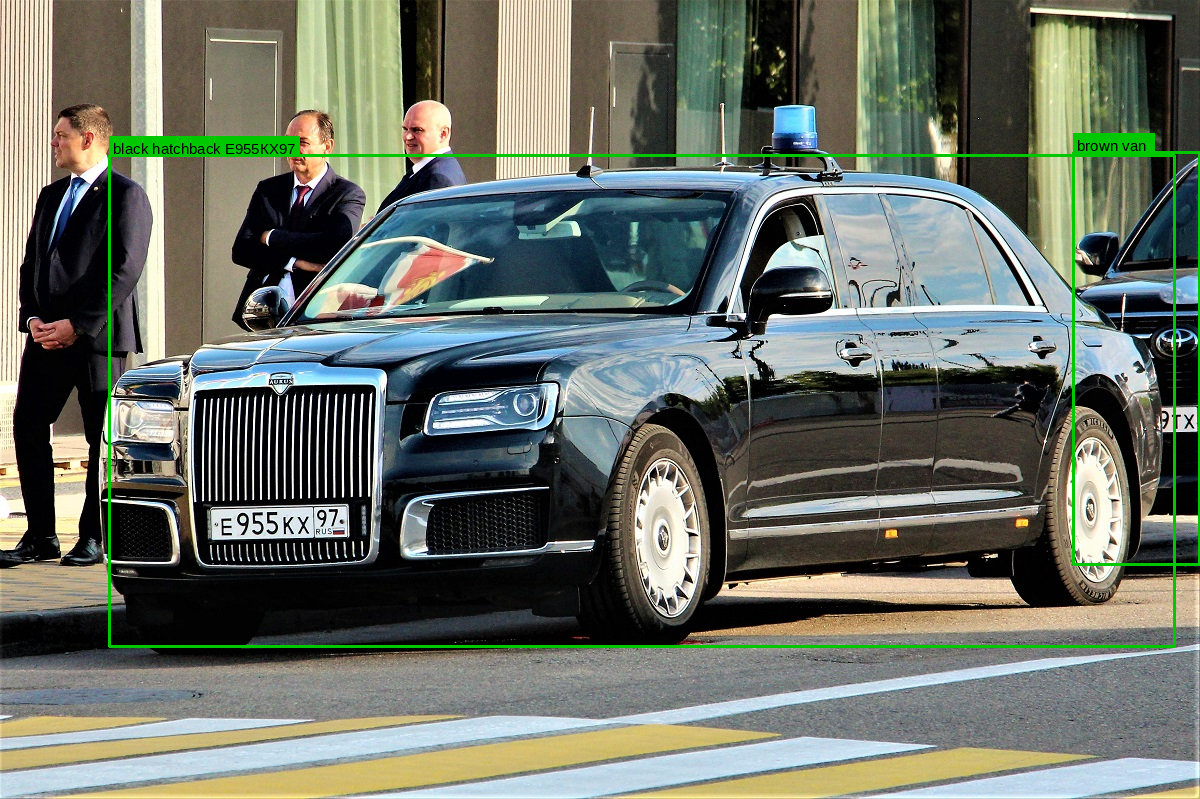

In [5]:
# ── Загрузка тестового изображения ────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()
TEST_IMG_PATH = list(uploaded.keys())[0]

frame = cv2.imread(TEST_IMG_PATH)
result_frame, detected = process_frame(frame)

print(f'Найдено объектов: {len(detected)}')
for v in detected:
    print(f'  {v["class"]:10s}  цвет={v["color"]} ({v["color_conf"]:.2f})  '
          f'кузов={v["body"]} ({v["body_conf"]:.2f})  номер={v["plate"]}')

cv2.imwrite(str(OUTPUT_DIR / 'test_single_frame.jpg'), result_frame)
cv2_imshow(result_frame)

## 4. Обработка видеофайла

**Загрузите видео перед запуском:**
```python
from google.colab import files
uploaded = files.upload()  # выберите MP4
TEST_VIDEO_PATH = list(uploaded.keys())[0]
```

In [6]:
TEST_VIDEO_PATH = '/content/your_video.mp4'   # ← изменить на путь к своему файлу

if not Path(TEST_VIDEO_PATH).exists():
    print(f'Файл не найден: {TEST_VIDEO_PATH}')
    print('Загрузите видео (см. ячейку выше) и укажите путь в TEST_VIDEO_PATH')
else:
    cap    = cv2.VideoCapture(TEST_VIDEO_PATH)
    w      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps_in = cap.get(cv2.CAP_PROP_FPS) or 25
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    out    = cv2.VideoWriter(str(OUTPUT_DIR / 'output_video.mp4'),
                             cv2.VideoWriter_fourcc(*'mp4v'), fps_in, (w,h))
    all_detections = []
    t0, n_proc = time.time(), 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        result_frame, vehicles = process_frame(frame)
        out.write(result_frame)
        all_detections.extend(vehicles)
        n_proc += 1
        if n_proc % 30 == 0:
            fps_proc = n_proc / (time.time() - t0)
            print(f'  Кадр {n_proc}/{total}  fps={fps_proc:.1f}  найдено={len(vehicles)}')
    cap.release(); out.release()
    elapsed = time.time() - t0
    avg_fps = n_proc / elapsed
    print(f'Обработано {n_proc} кадров за {elapsed:.1f}s  ({avg_fps:.1f} fps)')
    print(f'Видео сохранено: {OUTPUT_DIR}/output_video.mp4')
    print(f'Всего детекций: {len(all_detections)}')

Файл не найден: /content/your_video.mp4
Загрузите видео (см. ячейку выше) и укажите путь в TEST_VIDEO_PATH


## 5. Статистика обнаружений

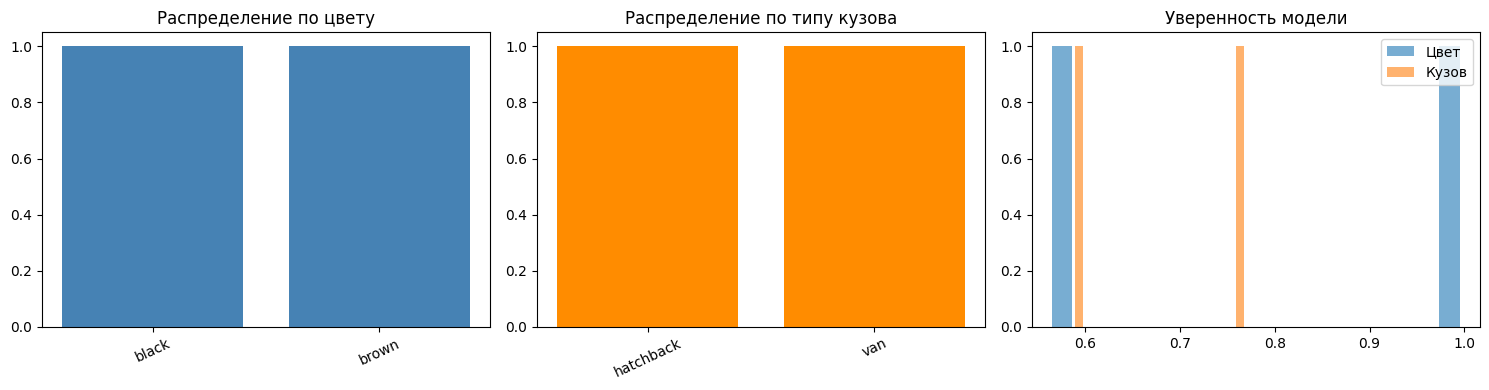

Всего детекций:  2
Номеров найдено: 1
Примеры: ['Е955КХ97']
TensorBoard логи сохранены → diploma_04_pipeline/output/tb_logs


In [7]:
# ── Использование результатов из тестового кадра (если видео не запускалось) ──
if 'all_detections' not in dir() or len(all_detections) == 0:
    all_detections = detected

if len(all_detections) == 0:
    print('Нет детекций для анализа.')
else:
    df = pd.DataFrame(all_detections)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Цвет
    color_counts = df['color'].value_counts()
    axes[0].bar(color_counts.index, color_counts.values, color='steelblue')
    axes[0].set_title('Распределение по цвету')
    axes[0].tick_params(axis='x', rotation=25)

    # Кузов
    body_counts = df['body'].value_counts()
    axes[1].bar(body_counts.index, body_counts.values, color='darkorange')
    axes[1].set_title('Распределение по типу кузова')
    axes[1].tick_params(axis='x', rotation=25)

    # Уверенность
    axes[2].hist(df['color_conf'], bins=20, alpha=0.6, label='Цвет')
    axes[2].hist(df['body_conf'],  bins=20, alpha=0.6, label='Кузов')
    axes[2].set_title('Уверенность модели'); axes[2].legend()

    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / 'stats_distributions.png'), dpi=130, bbox_inches='tight')
    plt.show()

    plates_found = [v['plate'] for v in all_detections if v['plate']]
    print(f'Всего детекций:  {len(all_detections)}')
    print(f'Номеров найдено: {len(plates_found)}')
    if plates_found:
        print('Примеры:', plates_found[:10])


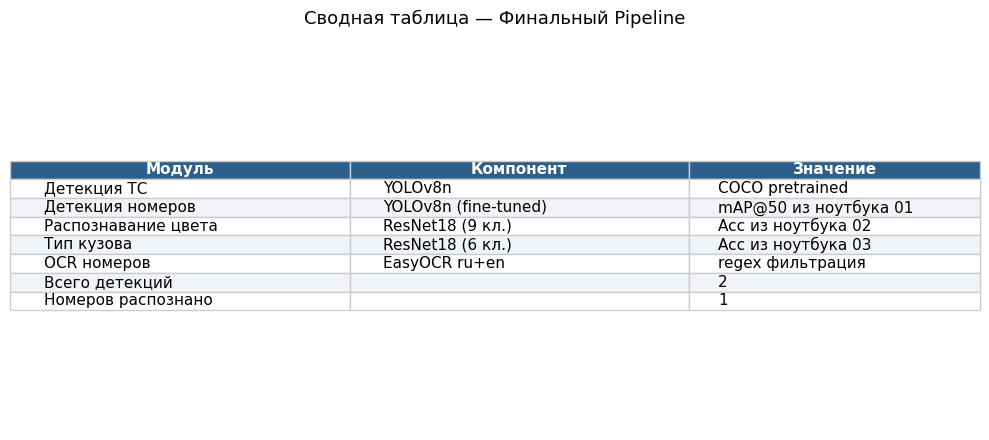

═══════════════════════════════════════════════════════
  Финальный pipeline — ИТОГ
  device                   : cuda
  vehicle_model            : yolov8n.pt
  color_model              : /content/drive/MyDrive/diploma/models/color_resnet18.pth
  body_model               : /content/drive/MyDrive/diploma/models/body_resnet18.pth
  plates_model             : /content/drive/MyDrive/diploma/models/yolov8n_plates.pt
  total_detections         : 2
  plates_found             : 1
═══════════════════════════════════════════════════════


In [8]:
# ── Сводная таблица ───────────────────────────────────────────────────────────
final_results = {
    'device': DEVICE,
    'vehicle_model': VEHICLE_MODEL_PATH,
    'color_model':   str(COLOR_MODEL_PATH),
    'body_model':    str(BODY_MODEL_PATH),
    'plates_model':  str(PLATES_MODEL_PATH),
    'total_detections': len(all_detections),
    'plates_found': len([v for v in all_detections if v['plate']]),
}
with open(OUTPUT_DIR / 'results.json', 'w', encoding='utf-8') as f:
    json.dump(final_results, f, ensure_ascii=False, indent=2)

rows = [
    ['Модуль', 'Компонент', 'Значение'],
    ['Детекция ТС', 'YOLOv8n', 'COCO pretrained'],
    ['Детекция номеров', 'YOLOv8n (fine-tuned)', 'mAP@50 из ноутбука 01'],
    ['Распознавание цвета', f'ResNet18 (9 кл.)', 'Acc из ноутбука 02'],
    ['Тип кузова', f'ResNet18 (6 кл.)', 'Acc из ноутбука 03'],
    ['OCR номеров', 'EasyOCR ru+en', 'regex фильтрация'],
    ['Всего детекций', '', str(len(all_detections))],
    ['Номеров распознано', '', str(len([v for v in all_detections if v['plate']]))],
]

fig, ax = plt.subplots(figsize=(10, len(rows)*0.5+0.5))
ax.axis('off')
tbl = ax.table(cellText=rows[1:], colLabels=rows[0],
               cellLoc='left', loc='center',
               colWidths=[0.35, 0.35, 0.3])
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
for (r,c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor('#2c5f8a'); cell.set_text_props(color='white', weight='bold')
    elif r % 2 == 0: cell.set_facecolor('#f0f4f8')
    cell.set_edgecolor('#cccccc')
plt.title('Сводная таблица — Финальный Pipeline', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'summary_table.png'), dpi=130, bbox_inches='tight')
plt.show()

print('═' * 55)
print('  Финальный pipeline — ИТОГ')
for k, v in final_results.items():
    print(f'  {k:25s}: {v}')
print('═' * 55)

In [9]:
# ── Скачать результаты ────────────────────────────────────────────────────────
if IN_COLAB:
    import zipfile
    from google.colab import files
    with zipfile.ZipFile('results_04_pipeline.zip', 'w') as zf:
        for p in OUTPUT_DIR.glob('*'): zf.write(p, p.name)
    files.download('results_04_pipeline.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>